In [1]:
library(DESeq2)
library(ggplot2)
library(rtracklayer)
library(pheatmap)
library(RColorBrewer)
library(ggrepel)
library(reshape2)
library(dplyr)
library(data.table)
library(tidyverse)
library(tidyr)
library(ggpubr)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loading required package: SummarizedExperiment

Loading required package: MatrixGe

ERROR: Error in library(tidyverse): there is no package called ‘tidyverse’


# Notes:
Scaling was done incorrectly, this makes quite a bit of difference for the final heatmap plots, e.g. for clustering

What is this normalisation method? how does rlog compare to vst, and what does DESeq recommend? I saw they had a new code

In [2]:
countData <- as.matrix(read.csv('gene_count_matrix_epiblast.csv', row.names = 'gene_id'))
colData <- read.csv('phenodata_epi2.csv', row.names = 1)

In [4]:
#E5.5, E6.5, E7.5
##Remove ex5.5 results
#select E7.5 data
colE567 <- colData[colData$stage!="ex5.5",]
#remove E7.5_WT_3
colE567 <- colE567[!rownames(colE567) %in% c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3"), ]
colE567$genotype <- factor(colE567$genotype, levels = c("WT", "Stat3-/-"))
countDataE567 <- countData[, rownames(colE567)]
head(countDataE567)

,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
ENSMUSG00000051951.5|Xkr4,5,11,6,4,48,0,96,94,76,142,⋯,215,235,232,134,170,315,138,178,166,180
ENSMUSG00000102851.1|Gm18956,4,0,0,0,0,0,0,0,0,0,⋯,3,2,3,0,0,0,4,5,0,0
ENSMUSG00000103025.1|Gm37686,0,0,0,0,0,0,4,0,0,0,⋯,18,0,27,4,3,10,11,0,0,3
ENSMUSG00000089699.1|Gm1992,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000103201.1|Gm37329,5,11,20,0,0,0,0,4,13,22,⋯,48,10,9,13,9,0,23,8,18,0
ENSMUSG00000103161.1|Gm38148,19,23,11,0,7,0,33,57,43,53,⋯,80,6,50,47,25,43,8,36,63,91


In [5]:
##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)
all(rownames(colE567) %in% colnames(countDataE567))
countDataE567 <- countDataE567[, rownames(colE567)]
all(rownames(colE567) == colnames(countDataE567))

[1] TRUE

[1] TRUE

In [6]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE567 <-DESeqDataSetFromMatrix(countData = countDataE567, colData = colE567, design = ~ genotype + stage + genotype:stage)
ddsFullE567 <- ddsFullE567[rowSums(counts(ddsFullE567)) > 0, ]


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [7]:

##Run the default analysis for DESeq2 and generate results table (デフォルトでDESeq2による解析を行い、結果を表にまとめる)

dds_E567 <- DESeq(ddsFullE567)
resultsNames(dds_E567)
res_E567 <- results(dds_E567, contrast = list(c("genotype_Stat3..._vs_WT", "genotypeStat3....stageE6.5")))
#Sort by adjusted p-value and display (P-Valueによって結果をソートする)
res_E567 <- res_E567[order(res_E567$padj), ]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This 

[1] "Intercept"                  "genotype_Stat3..._vs_WT"   
[3] "stage_E6.5_vs_E5.5"         "stage_E7.5_vs_E5.5"        
[5] "genotypeStat3....stageE6.5" "genotypeStat3....stageE7.5"

In [166]:
res_E567

log2 fold change (MLE): genotype_Stat3..._vs_WT+genotypeStat3....stageE6.5 effect 
Wald test p-value: genotype_Stat3..._vs_WT+genotypeStat3....stageE6.5 effect 
DataFrame with 31940 rows and 7 columns
            baseMean log2FoldChange     lfcSE        stat      pvalue
           <numeric>      <numeric> <numeric>   <numeric>   <numeric>
Pax3         33.4552       29.80229  2.180885    13.66523 1.63791e-42
Serpinb6c    28.5113       20.09205  2.072894     9.69275 3.23680e-22
Fgfr3       408.6626        3.97828  0.422559     9.41473 4.74312e-21
Trpm6       490.8932        5.39332  0.581083     9.28149 1.67124e-20
Apob      33962.0843        4.95920  0.565174     8.77465 1.71430e-18
...              ...            ...       ...         ...         ...
Gm28018    0.1555056      -0.619116   4.70432 -0.13160597    0.895296
Gm29512    0.3665973      -0.041968   4.70432 -0.00892116    0.992882
Gm29368    1.7951362       5.507298   4.63439  1.18835498          NA
Gm28480    0.0406745       0.

In [8]:
##gene_idとgene_nameを分離

gene_name <- rownames(res_E567)
gene_name_split <- strsplit(gene_name, "\\|")
head(gene_name_split)
rownames(res_E567) <- sapply(gene_name_split, "[", 2)
res_E567$gene_id <- sapply(gene_name_split, "[", 1)

library(stringr)
res_E567$gene_id <- str_replace(res_E567$gene_id,
                        pattern = ".[0-9]+$",
                        replacement = "")

head(res_E567)


[[1]]
[1] "ENSMUSG00000004872.15" "Pax3"                 

[[2]]
[1] "ENSMUSG00000052180.14" "Serpinb6c"            

[[3]]
[1] "ENSMUSG00000054252.17" "Fgfr3"                

[[4]]
[1] "ENSMUSG00000024727.8" "Trpm6"               

[[5]]
[1] "ENSMUSG00000020609.14" "Apob"                 

[[6]]
[1] "ENSMUSG00000052854.15" "Nrk"

log2 fold change (MLE): genotype_Stat3..._vs_WT+genotypeStat3....stageE6.5 effect 
Wald test p-value: genotype_Stat3..._vs_WT+genotypeStat3....stageE6.5 effect 
DataFrame with 6 rows and 7 columns
            baseMean log2FoldChange     lfcSE      stat      pvalue        padj
           <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
Pax3         33.4552       29.80229  2.180885  13.66523 1.63791e-42 3.18426e-38
Serpinb6c    28.5113       20.09205  2.072894   9.69275 3.23680e-22 3.14633e-18
Fgfr3       408.6626        3.97828  0.422559   9.41473 4.74312e-21 3.07370e-17
Trpm6       490.8932        5.39332  0.581083   9.28149 1.67124e-20 8.12263e-17
Apob      33962.0843        4.95920  0.565174   8.77465 1.71430e-18 6.66553e-15
Nrk        3502.1601        4.00620  0.457711   8.75268 2.08352e-18 6.75095e-15
                     gene_id
                 <character>
Pax3      ENSMUSG00000004872
Serpinb6c ENSMUSG00000052180
Fgfr3     ENSMUSG00000054252
Trpm6     ENSMUSG0

In [9]:
#E567 res sig genes

SIGS = res_E567[ which(res_E567$padj < 0.05 & abs(res_E567$log2FoldChange) > 2), ]
allSIG<- rownames(SIGS)
length(allSIG)

[1] 443

In [11]:
##Normalization

#relevels to WT
dds_E567$genotype <- factor(dds_E567$genotype, levels = c("WT", "Stat3-/-"))
#normalization
vst_E567 <- vst(dds_E567, blind = FALSE)
vst_E567$genotype <- factor(vst_E567$genotype, levels = c("WT", "Stat3-/-"))
rld_E567 <- rlog(dds_E567, blind = TRUE)
rld_E567$genotype <- factor(rld_E567$genotype, levels = c("WT", "Stat3-/-"))

In [12]:
##gene_idとgene_nameを分離　(rld_E567)

gene_name <- rownames(rld_E567)
gene_name_split <- strsplit(gene_name, "\\|")
head(gene_name_split)
rownames(rld_E567) <- sapply(gene_name_split, "[", 2)
head(rld_E567)

[[1]]
[1] "ENSMUSG00000051951.5" "Xkr4"                

[[2]]
[1] "ENSMUSG00000102851.1" "Gm18956"             

[[3]]
[1] "ENSMUSG00000103025.1" "Gm37686"             

[[4]]
[1] "ENSMUSG00000103201.1" "Gm37329"             

[[5]]
[1] "ENSMUSG00000103161.1" "Gm38148"             

[[6]]
[1] "ENSMUSG00000103377.1" "Gm37180"

class: DESeqTransform 
dim: 6 27 
metadata(1): version
assays(1): ''
rownames(6): Xkr4 Gm18956 ... Gm38148 Gm37180
rowData names(40): baseMean baseVar ... dispFit rlogIntercept
colnames(27): E5.5_Stat3null_2 E5.5_Stat3null_3 ... E7.5_WT_8 E7.5_WT_9
colData names(5): stage genotype cluster sizeFactor replaceable

In [13]:
#E7.5 data

#select E7.5 data
colE7 <- colData[colData$stage=="E7.5",]
#remove "E7.5_WT_3"
colE7 <- colE7[!rownames(colE7) %in% c("E7.5_WT_3"), ]
countDataE7 <- countData[, rownames(colE7)]
colnames(countDataE7)

[1] "E7.5_Stat3null_1" "E7.5_Stat3null_2" "E7.5_Stat3null_3" "E7.5_WT_1"       
 [5] "E7.5_WT_2"        "E7.5_WT_4"        "E7.5_WT_5"        "E7.5_WT_6"       
 [9] "E7.5_WT_7"        "E7.5_WT_8"        "E7.5_WT_9"

In [14]:
##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)

all(rownames(colE7) %in% colnames(countDataE7))
countDataE7 <- countDataE7[, rownames(colE7)]
all(rownames(colE7) == colnames(countDataE7))


[1] TRUE

[1] TRUE

In [15]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE7 <-DESeqDataSetFromMatrix(countData = countDataE7, colData = colE7, design = ~ genotype)
ddsFullE7 <- ddsFullE7[rowSums(counts(ddsFullE7)) > 0, ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [16]:
##Run the default analysis for DESeq2 and generate results table (デフォルトでDESeq2による解析を行い、結果を表にまとめる)

dds_E7 <- DESeq(ddsFullE7)
resultsNames(dds_E7)
res_E7 <- results(dds_E7, contrast = c('genotype', "Stat3-/-", "WT"))
res_E7 <- res_E7[order(res_E7$padj), ]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This 

[1] "Intercept"               "genotype_WT_vs_Stat3..."

In [17]:
##gene_idとgene_nameを分離

gene_name <- rownames(res_E7)
gene_name_split <- strsplit(gene_name, "\\|")
head(gene_name_split)
rownames(res_E7) <- sapply(gene_name_split, "[", 2)
res_E7$gene_id <- sapply(gene_name_split, "[", 1)
head(res_E7)
library(stringr)
res_E7$gene_id <- str_replace(res_E7$gene_id,
                        pattern = ".[0-9]+$",
                        replacement = "")

[[1]]
[1] "ENSMUSG00000081683.5" "Fzd10"               

[[2]]
[1] "ENSMUSG00000020183.11" "Cpm"                  

[[3]]
[1] "ENSMUSG00000041842.15" "Fhdc1"                

[[4]]
[1] "ENSMUSG00000048528.7" "Nkx1-2"              

[[5]]
[1] "ENSMUSG00000027660.16" "Skil"                 

[[6]]
[1] "ENSMUSG00000013584.5" "Aldh1a2"

log2 fold change (MLE): genotype Stat3-/- vs WT 
Wald test p-value: genotype Stat3-/- vs WT 
DataFrame with 6 rows and 7 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue        padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
Fzd10     827.788       -3.63011  0.184524  -19.6729 3.68375e-86 7.43675e-82
Cpm      1237.920       -2.71605  0.150319  -18.0686 5.63168e-73 5.68462e-69
Fhdc1     818.575       -2.84320  0.165000  -17.2315 1.54143e-66 1.03728e-62
Nkx1-2   3121.641       -4.04996  0.245654  -16.4864 4.59370e-61 2.31844e-57
Skil     3625.241        2.17811  0.134764   16.1624 9.28202e-59 3.74771e-55
Aldh1a2  2735.357       -7.47237  0.506372  -14.7567 2.78693e-49 9.37709e-46
                      gene_id
                  <character>
Fzd10    ENSMUSG00000081683.5
Cpm     ENSMUSG00000020183.11
Fhdc1   ENSMUSG00000041842.15
Nkx1-2   ENSMUSG00000048528.7
Skil    ENSMUSG00000027660.16
Aldh1a2  ENSMUSG00000013584.5

In [18]:
##E7.5 DEGsを抽出

resE7Sigind = res_E7[ which(res_E7$padj < 0.05 & res_E7$log2FoldChange > 2), ]
resE7Sigrep = res_E7[ which(res_E7$padj < 0.05 & res_E7$log2FoldChange < -2), ]
resE7Sig = rbind(resE7Sigind, resE7Sigrep)
E7Sig_genes <- rownames(resE7Sig)
head(E7Sig_genes)
length(E7Sig_genes)

[1] "Skil"    "Fgf5"    "Adamts9" "Lhx1"    "L1td1"   "Prrg4"

[1] 806

In [19]:
##Normalization for E7

#relevels to WT
dds_E7$genotype <- factor(dds_E7$genotype, levels = c("WT", "Stat3-/-"))
#normalization
rld_E7 <- rlog(dds_E7, blind = TRUE)
rld_E7$genotype <- factor(rld_E7$genotype, levels = c("WT", "Stat3-/-"))

In [20]:
##gene_idとgene_nameを分離　(rld_E7)

gene_name <- rownames(rld_E7)
gene_name_split <- strsplit(gene_name, "\\|")
head(gene_name_split)
rownames(rld_E7) <- sapply(gene_name_split, "[", 2)
head(rld_E7)

[[1]]
[1] "ENSMUSG00000051951.5" "Xkr4"                

[[2]]
[1] "ENSMUSG00000102851.1" "Gm18956"             

[[3]]
[1] "ENSMUSG00000103025.1" "Gm37686"             

[[4]]
[1] "ENSMUSG00000103201.1" "Gm37329"             

[[5]]
[1] "ENSMUSG00000103161.1" "Gm38148"             

[[6]]
[1] "ENSMUSG00000103377.1" "Gm37180"

class: DESeqTransform 
dim: 6 11 
metadata(1): version
assays(1): ''
rownames(6): Xkr4 Gm18956 ... Gm38148 Gm37180
rowData names(24): baseMean baseVar ... dispFit rlogIntercept
colnames(11): E7.5_Stat3null_1 E7.5_Stat3null_2 ... E7.5_WT_8 E7.5_WT_9
colData names(5): stage genotype cluster sizeFactor replaceable

In [184]:
#Complexheatmap for E7.5 DEGs

library(ComplexHeatmap)
E7rldSig <- assay(rld_E7)[E7Sig_genes, ] 
topVarGenes7 <- head(order(rowVars(E7rldSig), decreasing = TRUE), 1000)
mat7 <- E7rldSig[topVarGenes7,]
#mat7 <- E7rldSig

#### I'm assuming this is meant to be a Z-score?
######## actual calculation is (x - mean(x)) / var(x), implemented in R as scale()
#mat7 <- mat7 - rowMeans(mat7)
mat7 <- t(scale(t(mat7)))

list = c("T", "Axin2", "Cer1", "Dkk1","Wnt3a", "Tbx3","Wnt6", "Wnt8a","Wnt5a", "Igf2", "Bmp2","Bmp4", "Bmp5", "Fgf5", "Fgf3","Fgf8", "Cer1", "Prdm1", "Nkx1-2", "Cubn", "Apoe1", "Spry4", "Tead1","Apob", "Id1","Apoa1", "Apoa4" , "Sox7", "Eomes", "Hoxb2", "Hoxb3","Gbx2", "Nodal", "Notch1", "Nanog", "Esrrb", "Tfcp2l1", "Meox1", "Meox2", "Meis1", "Meis2")
genelabs <- rowAnnotation(Genes = anno_mark(at=which(rownames(mat7) %in% list), labels = rownames(mat7)[which(rownames(mat7) %in% list)]))

#perform k-means with 4 centers and take a look at the gene-to-cluster assignment.
set.seed(19765208)
kclus <- kmeans(mat7, 2)

#use the split parameter of Heatmap() in order to split the heatmap based on the k-means result:
split <- paste0("Cluster\n", kclus$cluster)
# fix order of the clusters to have 1 to 4, top to bottom
split <- factor(split, levels = c('Cluster\n1', 'Cluster\n2'))

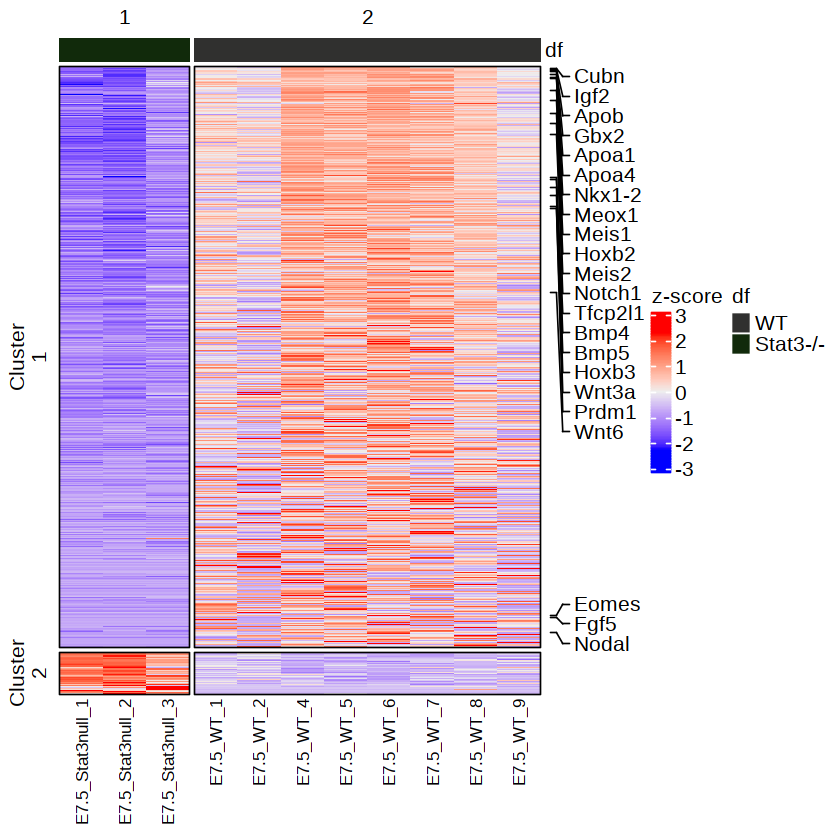

In [185]:
#top annotation
anno <- HeatmapAnnotation(df=colData(dds_E7)[, c("genotype")], col = list(genotype=c("WT"="#00afbb", "Stat3-/-"="#fc4e07")), annotation_legend_param = list(title_gp = gpar(fontsize = 12),labels_gp = gpar(fontsize = 12)))


hm7 <- Heatmap(mat7, split = split, name = "z-score", top_annotation = anno,
              cluster_row_slices = FALSE, 
              cluster_rows = FALSE,
              cluster_columns = FALSE,
              column_km = 2,
              show_row_dend = FALSE, 
              row_gap = unit(1, "mm"), 
              column_gap = unit(1, "mm"), 
              border = TRUE, 
              
              
              
              
              
              row_title_gp = gpar(fontsize = 12),
              row_names_gp = gpar(fontsize = 10), 
              column_title_gp = gpar(fontsize = 12), 
              column_names_gp = gpar(fontsize = 10),
              heatmap_legend_param = list(title_gp=gpar(fontsize = 12),
                                          labels_gp=gpar(fontsize = 12)
                                          )
              )
#pdf("Heatmap220422.pdf", width = 7.5, height = 10)
draw(hm7 + genelabs)
#dev.off()

In [23]:
#E6.5 data

#select E6.5 data
colE6 <- colData[colData$stage=="E6.5",]
#remove "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4"
colE6 <- colE6[!rownames(colE6) %in% c("E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4"), ]
countDataE6 <- countData[, rownames(colE6)]
colnames(countDataE6)

[1] "E6.5_Stat3null_3" "E6.5_Stat3null_4" "E6.5_Stat3null_5" "E6.5_Stat3null_6"
 [5] "E6.5_Stat3null_7" "E6.5_Stat3null_8" "E6.5_WT_5"        "E6.5_WT_6"       
 [9] "E6.5_WT_7"        "E6.5_WT_8"        "E6.5_WT_9"

In [24]:
##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)

all(rownames(colE6) %in% colnames(countDataE6))
countDataE6 <- countDataE6[, rownames(colE6)]
all(rownames(colE6) == colnames(countDataE6))

[1] TRUE

[1] TRUE

In [25]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE6 <-DESeqDataSetFromMatrix(countData = countDataE6, colData = colE6, design = ~ genotype)
ddsFullE6 <- ddsFullE6[rowSums(counts(ddsFullE6)) > 0, ]


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [26]:
##Run the default analysis for DESeq2 and generate results table (デフォルトでDESeq2による解析を行い、結果を表にまとめる)

dds_E6 <- DESeq(ddsFullE6)
resultsNames(dds_E6)
res_E6 <- results(dds_E6, contrast = c('genotype', "Stat3-/-", "WT"))
res_E6 <- res_E6[order(res_E6$padj), ]


##gene_idとgene_nameを分離

gene_name <- rownames(res_E6)
gene_name_split <- strsplit(gene_name, "\\|")
head(gene_name_split)
rownames(res_E6) <- sapply(gene_name_split, "[", 2)
res_E6$gene_id <- sapply(gene_name_split, "[", 1)
head(res_E6)
library(stringr)
res_E6$gene_id <- str_replace(res_E6$gene_id,
                        pattern = ".[0-9]+$",
                        replacement = "")

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This 

[1] "Intercept"               "genotype_WT_vs_Stat3..."

[[1]]
[1] "ENSMUSG00000000142.15" "Axin2"                

[[2]]
[1] "ENSMUSG00000021765.7" "Fst"                 

[[3]]
[1] "ENSMUSG00000017950.16" "Hnf4a"                

[[4]]
[1] "ENSMUSG00000038729.20" "Akap2"                

[[5]]
[1] "ENSMUSG00000054252.17" "Fgfr3"                

[[6]]
[1] "ENSMUSG00000022180.6" "Slc7a8"

log2 fold change (MLE): genotype Stat3-/- vs WT 
Wald test p-value: genotype Stat3-/- vs WT 
DataFrame with 6 rows and 7 columns
        baseMean log2FoldChange     lfcSE      stat      pvalue        padj
       <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
Axin2   2316.087       -1.40070  0.124072 -11.28941 1.48034e-29 2.42391e-25
Fst     1372.772       -2.25028  0.251368  -8.95213 3.48674e-19 2.85459e-15
Hnf4a   1084.796        4.02178  0.455234   8.83453 1.00520e-18 5.48638e-15
Akap2    936.999        1.75036  0.210101   8.33106 8.01225e-17 3.27982e-13
Fgfr3    111.691        3.96933  0.485376   8.17784 2.88966e-16 9.46306e-13
Slc7a8   837.496        4.24291  0.529264   8.01662 1.08692e-15 2.79953e-12
                     gene_id
                 <character>
Axin2  ENSMUSG00000000142.15
Fst     ENSMUSG00000021765.7
Hnf4a  ENSMUSG00000017950.16
Akap2  ENSMUSG00000038729.20
Fgfr3  ENSMUSG00000054252.17
Slc7a8  ENSMUSG00000022180.6

In [27]:
##E6.5 DEGsを抽出

resE6Sigind = res_E6[ which(res_E6$padj < 0.05 & res_E6$log2FoldChange > 2), ]
resE6Sigrep = res_E6[ which(res_E6$padj < 0.05 & res_E6$log2FoldChange < -2), ]
resE6Sig = rbind(resE6Sigind, resE6Sigrep)
E6Sig_genes <- rownames(resE6Sig)
head(E6Sig_genes)
length(E6Sig_genes)

[1] "Hnf4a"  "Fgfr3"  "Slc7a8" "Clic6"  "Hnf1b"  "Apom"

[1] 318

In [28]:
#E5.5 data

#select E5.5 data
colE5 <- colData[colData$stage=="E5.5",]

colE5 <- colE5[!rownames(colE5) %in% c("E5.5_Stat3null_1"), ]
countDataE5 <- countData[, rownames(colE5)]
colnames(countDataE5)

##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)

all(rownames(colE5) %in% colnames(countDataE5))
countDataE5 <- countDataE5[, rownames(colE5)]
all(rownames(colE5) == colnames(countDataE5))


[1] "E5.5_Stat3null_2" "E5.5_Stat3null_3" "E5.5_Stat3null_4" "E5.5_WT_1"       
[5] "E5.5_WT_2"

[1] TRUE

[1] TRUE

In [29]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE5 <-DESeqDataSetFromMatrix(countData = countDataE5, colData = colE5, design = ~ genotype)
ddsFullE5 <- ddsFullE5[rowSums(counts(ddsFullE5)) > 0, ]


##Run the default analysis for DESeq2 and generate results table (デフォルトでDESeq2による解析を行い、結果を表にまとめる)

dds_E5 <- DESeq(ddsFullE5)
resultsNames(dds_E5)
res_E5 <- results(dds_E5, contrast = c('genotype', "Stat3-/-", "WT"))
#Sort by adjusted p-value and display (P-Valueによって結果をソートする)
res_E5 <- res_E5[order(res_E5$padj), ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
 

[1] "Intercept"               "genotype_WT_vs_Stat3..."

In [30]:
#gene_idとgene_nameを分離

gene_name <- rownames(res_E5)
gene_name_split <- strsplit(gene_name, "\\|")
head(gene_name_split)
rownames(res_E5) <- sapply(gene_name_split, "[", 2)
res_E5$gene_id <- sapply(gene_name_split, "[", 1)
head(res_E5)
library(stringr)
res_E5$gene_id <- str_replace(res_E5$gene_id,
                        pattern = ".[0-9]+$",
                        replacement = "")



##E5.5 DEGsを抽出

resE5Sigind = res_E5[ which(res_E5$padj < 0.05 & res_E5$log2FoldChange > 2), ]
resE5Sigrep = res_E5[ which(res_E5$padj < 0.05 & res_E5$log2FoldChange < -2), ]
resE5Sig = rbind(resE5Sigind, resE5Sigrep)
E5Sig_genes <- rownames(resE5Sig)
head(E5Sig_genes)
length(E5Sig_genes)

[[1]]
[1] "ENSMUSG00000102976.5" "Zc3h11a"             

[[2]]
[1] "ENSMUSG00000070047.12" "Fat1"                 

[[3]]
[1] "ENSMUSG00000099908.1" "Gm28539"             

[[4]]
[1] "ENSMUSG00000107169.1" "Gm43796"             

[[5]]
[1] "ENSMUSG00000045246.11" "Kcng4"                

[[6]]
[1] "ENSMUSG00000040065.8" "Pfpl"

log2 fold change (MLE): genotype Stat3-/- vs WT 
Wald test p-value: genotype Stat3-/- vs WT 
DataFrame with 6 rows and 7 columns
          baseMean log2FoldChange     lfcSE      stat      pvalue        padj
         <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
Zc3h11a  3110.3161       1.541293  0.238075   6.47399 9.54484e-11 1.05427e-06
Fat1    14627.4532      -0.662869  0.102757  -6.45081 1.11256e-10 1.05427e-06
Gm28539    26.3642      21.376117  3.708748   5.76370 8.22889e-09 4.62863e-05
Gm43796   181.2856     -24.570961  4.328265  -5.67686 1.37189e-08 4.62863e-05
Kcng4      25.1334      21.311719  3.761620   5.66557 1.46537e-08 4.62863e-05
Pfpl       71.6980      -9.995591  1.763803  -5.66707 1.45263e-08 4.62863e-05
                      gene_id
                  <character>
Zc3h11a  ENSMUSG00000102976.5
Fat1    ENSMUSG00000070047.12
Gm28539  ENSMUSG00000099908.1
Gm43796  ENSMUSG00000107169.1
Kcng4   ENSMUSG00000045246.11
Pfpl     ENSMUSG00000040065.8

[1] "Gm28539"       "Kcng4"         "Hsd17b2"       "4933433G15Rik"
[5] "Cspg4"         "Ccdc42"

[1] 98

In [31]:
##Merge E5, E6, E7 sig genes

E567Sig <-union(E5Sig_genes, E6Sig_genes) %>% union(., E7Sig_genes) 
length(E567Sig)


##Normalization

#relevels to WT
dds_E567$genotype <- factor(dds_E567$genotype, levels = c("WT", "Stat3-/-"))
#normalization
vst_E567 <- vst(dds_E567, blind = FALSE)
vst_E567$genotype <- factor(vst_E567$genotype, levels = c("WT", "Stat3-/-"))
rld_E567 <- rlog(dds_E567, blind = TRUE)
rld_E567$genotype <- factor(rld_E567$genotype, levels = c("WT", "Stat3-/-"))



##gene_idとgene_nameを分離　(rld_E567)

gene_name <- rownames(rld_E567)
gene_name_split <- strsplit(gene_name, "\\|")
head(gene_name_split)
rownames(rld_E567) <- sapply(gene_name_split, "[", 2)
head(rld_E567)


[1] 1074

[[1]]
[1] "ENSMUSG00000051951.5" "Xkr4"                

[[2]]
[1] "ENSMUSG00000102851.1" "Gm18956"             

[[3]]
[1] "ENSMUSG00000103025.1" "Gm37686"             

[[4]]
[1] "ENSMUSG00000103201.1" "Gm37329"             

[[5]]
[1] "ENSMUSG00000103161.1" "Gm38148"             

[[6]]
[1] "ENSMUSG00000103377.1" "Gm37180"

class: DESeqTransform 
dim: 6 27 
metadata(1): version
assays(1): ''
rownames(6): Xkr4 Gm18956 ... Gm38148 Gm37180
rowData names(40): baseMean baseVar ... dispFit rlogIntercept
colnames(27): E5.5_Stat3null_2 E5.5_Stat3null_3 ... E7.5_WT_8 E7.5_WT_9
colData names(5): stage genotype cluster sizeFactor replaceable

In [186]:
#Complexheatmap

library(ComplexHeatmap)
rldSig <- assay(rld_E567)[E567Sig, ] 
topVarGenes <- head(order(rowVars(rldSig), decreasing = TRUE), 1000)
mat <- rldSig[topVarGenes,]
#mat <- mat - rowMeans(mat)
mat <- t(scale(t(mat)))

list = c("T", "Axin2", "Cer1", "Dkk1","Wnt3a", "Tbx3","Wnt6", "Wnt8a","Wnt5a", "Igf2", "Bmp2","Bmp4", "Bmp5", "Fgf5", "Fgf3","Fgf8", "Cer1", "Prdm1", "Nkx1-2", "Cubn", "Apoe1", "Spry4", "Tead1","Apob", "Id1","Apoa1", "Apoa4" , "Sox7", "Eomes", "Hoxb2", "Hoxb3","Gbx2", "Nodal", "Notch1", "Nanog", "Esrrb", "Tfcp2l1", "Meox1", "Meox2", "Meis1", "Meis2")
genelabs <- rowAnnotation(Genes = anno_mark(at=which(rownames(mat) %in% list), labels = rownames(mat)[which(rownames(mat) %in% list)]))

#perform k-means with 4 centers and take a look at the gene-to-cluster assignment.
set.seed(1937623879)
kclus <- kmeans(mat, 5)

#use the split parameter of Heatmap() in order to split the heatmap based on the k-means result:
split <- paste0("Cluster\n", kclus$cluster)
# fix order of the clusters to have 1 to 4, top to bottom
split <- factor(split, levels = c('Cluster\n1', 'Cluster\n2', 'Cluster\n3', 'Cluster\n4', 'Cluster\n5'))




#top annotation
anno <- HeatmapAnnotation(df=colData(dds_E567)[, c("genotype", "stage")], 
                          col = list(genotype=c("WT"="#00afbb", "Stat3-/-"="#fc4e07"), 
                                     stage=c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")),
                          annotation_legend_param = list(title_gp = gpar(fontsize = 12),
                                                         labels_gp = gpar(fontsize = 12)))


hm <- Heatmap(mat, split = split, name = "z-score", top_annotation = anno,
              cluster_row_slices = FALSE, 
              cluster_rows = FALSE,
              column_split = rld_E567$cluster, 
              cluster_columns = FALSE,
              show_row_dend = FALSE, 
              row_gap = unit(1, "mm"), 
              column_gap = unit(1, "mm"), 
              border = TRUE, 
              row_title_gp = gpar(fontsize = 12),
              row_names_gp = gpar(fontsize = 10), 
              column_title_gp = gpar(fontsize = 12), 
              column_names_gp = gpar(fontsize = 10),
              heatmap_legend_param = list(title_gp=gpar(fontsize = 12),
                                          labels_gp=gpar(fontsize = 12)
                                          )
              )
pdf("Heatmap100522_c5.pdf", width = 7.5, height = 10)
draw(hm + genelabs)
dev.off()

png 
  2

In [33]:
##subset cluster

clusterdfhm <- as.data.frame(factor(kclus$cluster))
colnames(clusterdfhm) <- "Cluster"
c1 <- filter(clusterdfhm, Cluster==1)
c2 <- filter(clusterdfhm, Cluster==2)
c3 <- filter(clusterdfhm, Cluster==3)
c4 <- filter(clusterdfhm, Cluster==4)
c5 <- filter(clusterdfhm, Cluster==5)

,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Hand1,11.005331,8.659533,11.040748,11.455154,8.831928,8.916532,8.113055,6.990890,7.616521,7.357926,⋯,6.725870,9.117456,9.629882,9.631783,10.847111,10.478815,11.051468,11.519423,10.361856,9.058763
Ahnak,12.678621,9.099778,12.799591,13.912581,9.382061,9.136154,9.692661,9.314309,8.906541,9.557774,⋯,8.144147,8.952198,10.995985,10.952352,12.939213,12.521599,12.735547,12.792570,11.600794,10.452815
Nrp1,8.507472,9.547426,8.285159,7.037547,7.439143,8.353113,8.504625,5.879126,6.308409,5.858009,⋯,7.027106,7.569728,8.864967,9.093617,10.476492,10.241638,10.233226,10.306136,10.027849,9.518671
Irx1,7.669868,8.423076,8.803040,10.017656,7.922745,7.644259,7.927638,7.275038,6.138192,6.279153,⋯,6.708437,8.134981,10.228933,10.152680,10.219541,9.991185,10.040188,9.799440,10.156851,10.241015
Meis1,7.897169,6.540036,8.053607,7.355959,6.058352,6.575707,7.102271,5.008101,4.609032,5.950029,⋯,5.134291,7.175045,8.918490,9.274593,9.888268,9.582601,8.933593,8.636008,9.083569,8.663424
Cer1,6.776813,7.778294,8.699526,9.314314,9.588774,7.589846,9.479753,7.578632,7.783886,6.435869,⋯,9.572544,10.261696,10.502127,10.949798,9.689583,9.654488,10.083581,9.954189,10.689866,10.799348


Warning message in melt(gene_c1, id.vars = c("gene")):
“The melt generic in data.table has been passed a matrix and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(gene_c1). In the next version, this warning will become an error.”


,gene,sample,normalized_count
,<fct>,<fct>,<dbl>
1,Hand1,E5.5_Stat3null_2,11.005331
2,Ahnak,E5.5_Stat3null_2,12.678621
3,Nrp1,E5.5_Stat3null_2,8.507472
4,Irx1,E5.5_Stat3null_2,7.669868
5,Meis1,E5.5_Stat3null_2,7.897169
6,Cer1,E5.5_Stat3null_2,6.776813


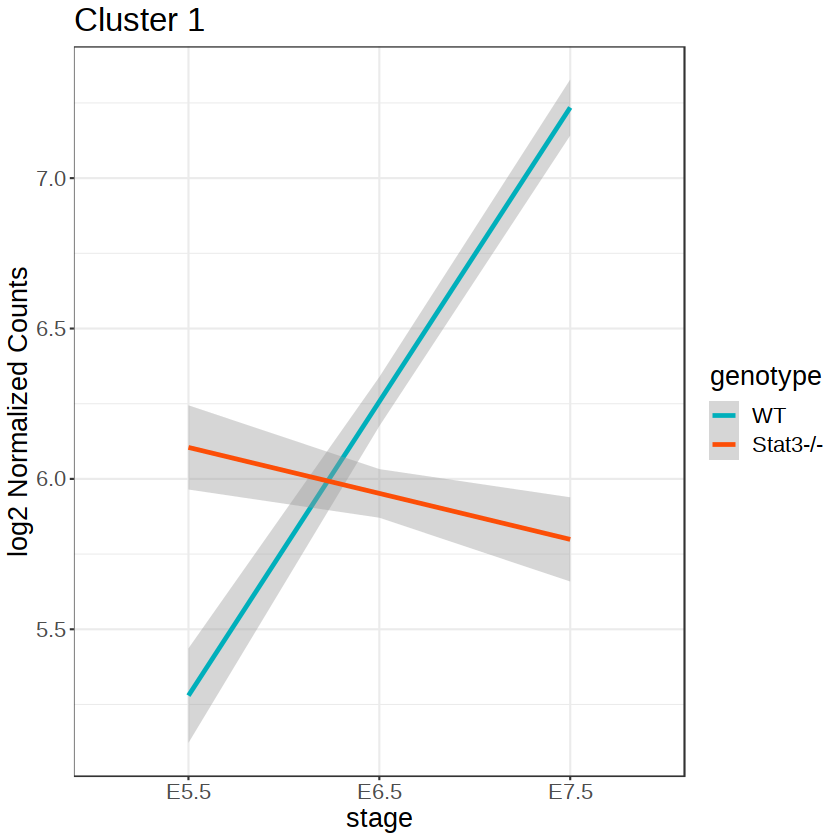

In [37]:
#Plot for gene of c1

rldE567 <- assay(rld_E567)
rldE567 <- as.data.frame(rldE567)
rldE567$gene <- rownames(rldE567)
#selected genes
c1genes <- rownames(c1)
gene_c1 <- assay(rld_E567[c1genes, ])
head(gene_c1)
# First compare wide vs long version
rldE567_c1_long <- melt(gene_c1, id.vars=c("gene"))
colnames(rldE567_c1_long) <- c("gene", "sample", "normalized_count")
head(rldE567_c1_long)

phenodata_epi <- read.csv("phenodata_epi2.csv")
rldE567_c1_long <- inner_join( phenodata_epi, rldE567_c1_long, by = "sample")
rldE567_c1_long$genotype <- factor(rldE567_c1_long$genotype, levels = c("WT", "Stat3-/-"))

#plot c1 genes
c1plot <- rldE567_c1_long %>%
  ggplot(aes(stage, normalized_count, group = genotype, color = genotype)) +
  scale_color_manual(values = c("#00afbb", "#fc4e07")) +
  geom_smooth(method = "lm", formula = 'y ~ x') +
  theme_bw(base_size = 10) +
  theme(text = element_text(size = 16)) +
  xlab("stage") +
  ylab("log2 Normalized Counts") +
  ggtitle("Cluster 1")

print(c1plot)

,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Hand1,11.005331,8.659533,11.040748,11.455154,8.831928,8.916532,8.113055,6.990890,7.616521,7.357926,⋯,6.725870,9.117456,9.629882,9.631783,10.847111,10.478815,11.051468,11.519423,10.361856,9.058763
Ahnak,12.678621,9.099778,12.799591,13.912581,9.382061,9.136154,9.692661,9.314309,8.906541,9.557774,⋯,8.144147,8.952198,10.995985,10.952352,12.939213,12.521599,12.735547,12.792570,11.600794,10.452815
Nrp1,8.507472,9.547426,8.285159,7.037547,7.439143,8.353113,8.504625,5.879126,6.308409,5.858009,⋯,7.027106,7.569728,8.864967,9.093617,10.476492,10.241638,10.233226,10.306136,10.027849,9.518671
Irx1,7.669868,8.423076,8.803040,10.017656,7.922745,7.644259,7.927638,7.275038,6.138192,6.279153,⋯,6.708437,8.134981,10.228933,10.152680,10.219541,9.991185,10.040188,9.799440,10.156851,10.241015
Meis1,7.897169,6.540036,8.053607,7.355959,6.058352,6.575707,7.102271,5.008101,4.609032,5.950029,⋯,5.134291,7.175045,8.918490,9.274593,9.888268,9.582601,8.933593,8.636008,9.083569,8.663424
Cer1,6.776813,7.778294,8.699526,9.314314,9.588774,7.589846,9.479753,7.578632,7.783886,6.435869,⋯,9.572544,10.261696,10.502127,10.949798,9.689583,9.654488,10.083581,9.954189,10.689866,10.799348


Warning message in melt(gene_c1, id.vars = c("gene")):
“The melt generic in data.table has been passed a matrix and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(gene_c1). In the next version, this warning will become an error.”


,gene,sample,normalized_count
,<fct>,<fct>,<dbl>
1,Hand1,E5.5_Stat3null_2,11.005331
2,Ahnak,E5.5_Stat3null_2,12.678621
3,Nrp1,E5.5_Stat3null_2,8.507472
4,Irx1,E5.5_Stat3null_2,7.669868
5,Meis1,E5.5_Stat3null_2,7.897169
6,Cer1,E5.5_Stat3null_2,6.776813


Warning message in write.csv(c1genes, "Cluster1Genes_100522.csv", row.names = F, :
“attempt to set 'col.names' ignored”


,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Aldh1a2,3.683910,4.736803,4.355624,3.613862,3.541565,3.298736,3.463471,3.479329,3.395713,5.306020,⋯,4.296984,5.096565,10.515770,9.845055,11.237495,11.388141,11.227376,10.154881,10.93823,9.843471
Cdx1,5.009721,3.266871,5.641410,6.055533,3.277479,3.055806,3.206042,3.220538,3.144164,3.272502,⋯,4.768092,3.071526,7.828596,6.932138,11.833564,11.961418,11.464007,8.556318,10.11796,7.877988
Hoxb1,4.158773,3.357871,3.239242,3.423549,3.366902,3.180766,3.306307,3.318558,3.910032,3.362664,⋯,4.019190,5.758890,9.654164,9.150189,9.204688,9.494385,9.489183,10.061506,10.18376,8.879938
Nkx1-2,4.788906,4.535574,4.115938,4.338422,4.269937,4.045520,5.110850,6.225161,5.182621,4.264817,⋯,7.222372,8.347142,11.159423,10.872817,11.012785,11.111910,11.196949,11.329052,11.46041,10.675295
Gbx2,5.606984,5.876853,6.276736,5.605094,4.767422,3.827232,4.726863,3.984355,3.910780,5.318790,⋯,5.366137,7.956125,10.517715,10.097093,10.802890,10.773037,10.770056,10.949572,10.80743,10.112504
T,5.217944,5.082068,4.952279,5.155376,5.800801,4.889579,6.351841,6.568145,7.631688,7.477556,⋯,10.655446,11.710393,12.080238,11.898465,10.746765,10.850121,11.028633,11.822794,11.77721,12.046408


Warning message in melt(gene_c2, id.vars = c("gene")):
“The melt generic in data.table has been passed a matrix and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(gene_c2). In the next version, this warning will become an error.”


,gene,sample,normalized_count
,<fct>,<fct>,<dbl>
1,Aldh1a2,E5.5_Stat3null_2,3.683910
2,Cdx1,E5.5_Stat3null_2,5.009721
3,Hoxb1,E5.5_Stat3null_2,4.158773
4,Nkx1-2,E5.5_Stat3null_2,4.788906
5,Gbx2,E5.5_Stat3null_2,5.606984
6,T,E5.5_Stat3null_2,5.217944


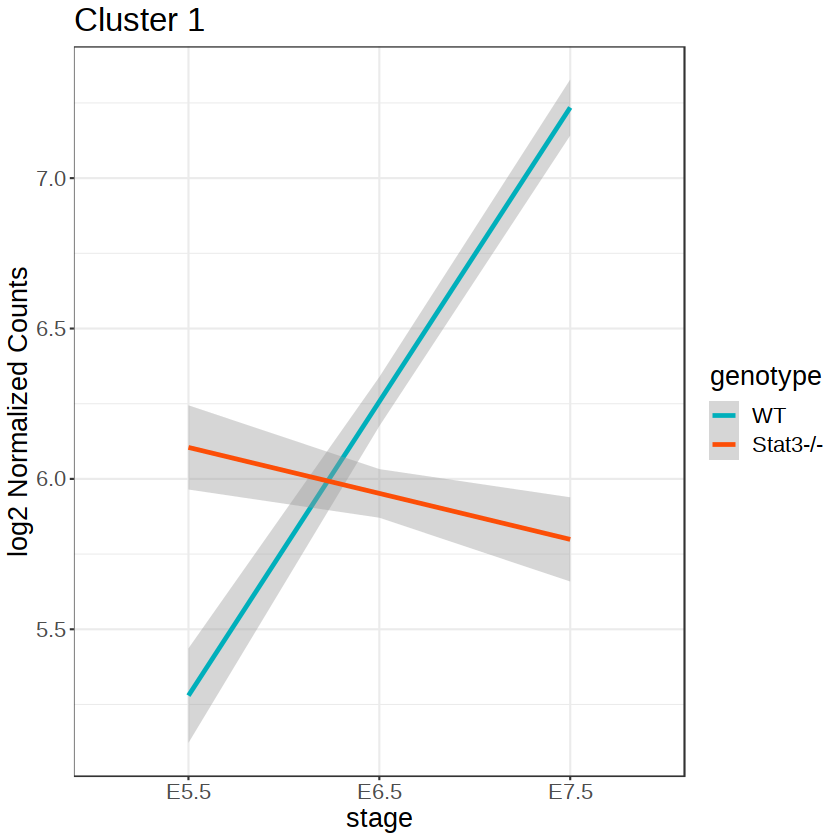

Warning message in write.csv(c2genes, "Cluster2Genes_100522.csv", row.names = F, :
“attempt to set 'col.names' ignored”


,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Gm4322,9.019012,5.730476,9.119421,5.605187,5.554379,9.104125,6.890955,9.553295,9.148369,9.111074,⋯,8.619640,9.658758,5.594885,5.859126,9.215971,9.458549,9.547638,9.737966,9.389152,9.285515
Gm28062,5.016405,5.114374,5.930916,4.772742,5.057714,4.373044,4.533912,5.070323,7.016841,7.437099,⋯,5.165511,5.110812,5.843721,5.496560,5.937640,7.904026,8.342268,5.191526,9.016032,4.446990
Gprc5a,6.977349,3.452861,6.750199,6.888460,3.901687,3.402863,3.982725,4.144979,4.076558,4.294420,⋯,3.418290,3.406275,4.512341,4.073306,5.483970,5.097942,4.998867,3.464956,4.798206,4.379539
Rps19-ps1,8.384958,8.195193,5.469946,7.304258,5.843485,4.858396,5.760456,8.132880,5.831207,5.697024,⋯,8.497053,5.452219,5.569057,5.838778,5.474087,5.756764,5.913272,6.762263,5.456166,7.145318
Gm12245,7.993136,5.560848,7.545208,5.562512,5.451944,7.249192,6.270033,8.025464,7.649881,7.720254,⋯,7.181751,8.219525,5.905753,5.692498,7.712775,7.663314,7.868971,7.954026,7.936893,8.061906
Lrrc8c,5.576676,5.524647,5.479555,7.005977,6.837611,7.190476,7.638107,7.553790,8.348065,8.396448,⋯,8.474434,7.979391,8.524956,8.765844,8.713804,8.606828,8.233902,8.095803,8.635994,8.218469


Warning message in melt(gene_c3, id.vars = c("gene")):
“The melt generic in data.table has been passed a matrix and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(gene_c3). In the next version, this warning will become an error.”


,gene,sample,normalized_count
,<fct>,<fct>,<dbl>
1,Gm4322,E5.5_Stat3null_2,9.019012
2,Gm28062,E5.5_Stat3null_2,5.016405
3,Gprc5a,E5.5_Stat3null_2,6.977349
4,Rps19-ps1,E5.5_Stat3null_2,8.384958
5,Gm12245,E5.5_Stat3null_2,7.993136
6,Lrrc8c,E5.5_Stat3null_2,5.576676


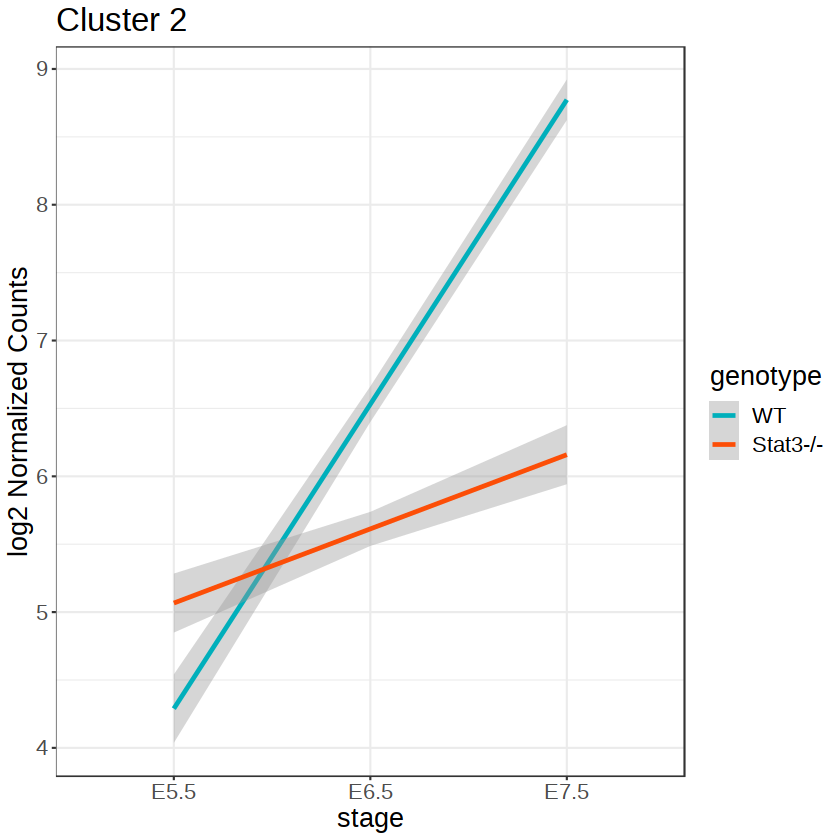

Warning message in write.csv(c3genes, "Cluster3Genes_100522.csv", row.names = F, :
“attempt to set 'col.names' ignored”


,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Tdgf1,9.538667,10.829155,10.068755,10.194130,10.86925,11.116023,10.611782,10.94078,10.988689,11.03149,⋯,10.908705,11.310347,6.172999,7.215992,5.577764,5.824750,5.877636,5.578378,7.217350,7.707221
Hrnr,7.542944,9.299937,9.188112,7.794366,8.84608,11.503588,9.309693,9.95754,10.160951,10.90693,⋯,8.917695,7.606621,6.217640,5.090659,5.086584,6.067212,6.132938,5.938837,5.673573,5.072488
Foxd3,8.519390,9.479954,9.113992,8.779600,9.40677,9.308094,9.622087,10.33704,10.237790,10.48319,⋯,10.376858,9.482343,5.312743,7.609895,5.475078,5.220920,5.364859,5.282500,6.017985,6.555496
Pmepa1,10.692657,11.033238,10.179022,10.437388,10.59303,10.598386,10.561050,10.61487,9.826454,10.44998,⋯,10.001566,8.086540,5.869704,7.559521,6.759715,5.387244,6.562714,6.556136,5.735571,6.090192
Eomes,13.466662,13.340912,13.253413,13.342119,12.96913,12.614948,12.434432,11.76514,11.683819,11.63822,⋯,13.291100,13.232006,9.685942,9.285049,8.101265,8.129173,8.839404,9.398894,9.855151,9.887100
Fgf5,11.412955,11.747658,11.356281,11.392433,11.76626,11.703833,11.656537,11.68081,11.558238,11.57648,⋯,11.740514,11.122261,8.077598,8.644364,7.838004,8.507218,8.138289,7.694257,8.427863,8.711474


Warning message in melt(gene_c4, id.vars = c("gene")):
“The melt generic in data.table has been passed a matrix and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(gene_c4). In the next version, this warning will become an error.”


,gene,sample,normalized_count
,<fct>,<fct>,<dbl>
1,Tdgf1,E5.5_Stat3null_2,9.538667
2,Hrnr,E5.5_Stat3null_2,7.542944
3,Foxd3,E5.5_Stat3null_2,8.519390
4,Pmepa1,E5.5_Stat3null_2,10.692657
5,Eomes,E5.5_Stat3null_2,13.466662
6,Fgf5,E5.5_Stat3null_2,11.412955


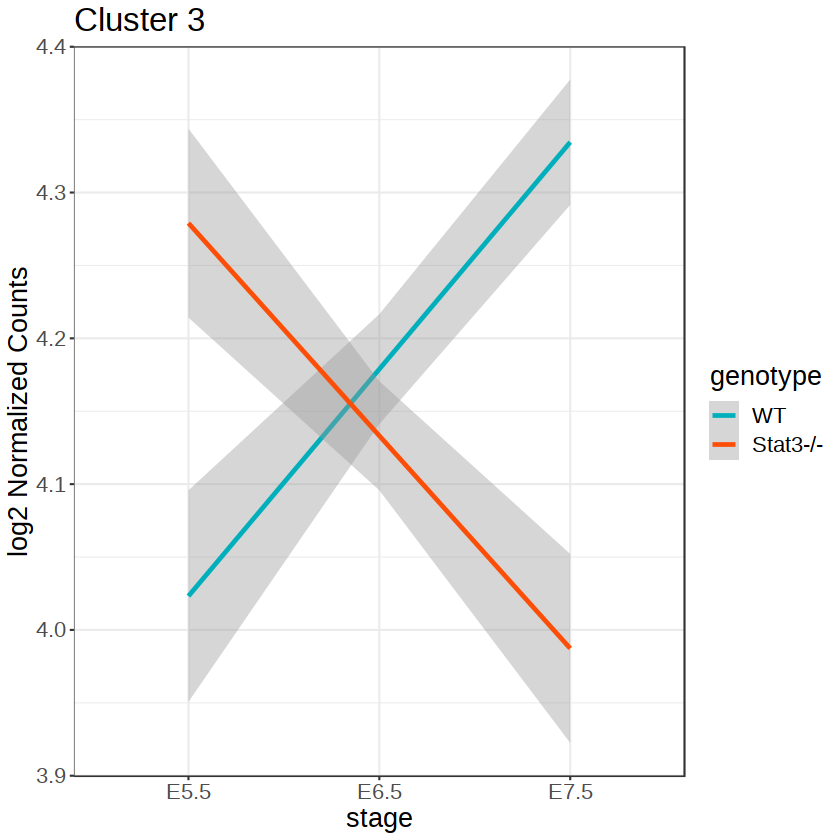

Warning message in write.csv(c4genes, "Cluster4Genes_100522.csv", row.names = F, :
“attempt to set 'col.names' ignored”


,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Srgn,11.40616,11.719347,11.139807,11.26899,11.601932,9.057450,9.228610,7.172964,6.726812,6.728099,⋯,3.841049,5.840050,5.783566,6.480218,4.037986,3.952283,3.846378,6.049363,4.537652,5.385776
Itga7,10.98190,4.843317,11.683400,11.70964,5.708321,6.003071,5.595974,4.933389,5.325416,5.750011,⋯,4.993273,3.131972,5.177866,4.540545,3.314771,3.252197,3.748993,4.251393,4.126172,3.301502
Pga5,10.17499,10.389858,10.090084,10.00081,10.703593,7.812968,7.788329,5.894917,4.984112,4.620508,⋯,4.954321,3.545806,4.553354,3.765671,5.628025,4.937491,5.984069,4.676156,3.675497,4.810675
Aqp8,10.37101,10.430717,8.357752,10.96683,8.468163,6.944237,5.548153,4.873006,3.477517,5.078381,⋯,3.465154,4.748314,3.558500,3.593739,5.549183,3.535099,5.074169,6.368023,4.604304,3.578577
Foxq1,10.46477,10.887351,10.080394,10.10190,10.580406,10.108048,10.225382,8.081413,7.222228,6.551626,⋯,5.492861,4.141734,5.006181,4.768229,4.530670,4.854598,4.732560,5.783857,5.289473,4.329428
Cubn,16.71828,16.917614,16.268301,16.13849,15.859239,15.424750,14.328445,12.304163,13.091613,12.039816,⋯,9.138031,11.410540,13.437444,12.541929,14.460409,13.840079,14.641792,14.735563,13.438974,12.661599


Warning message in melt(gene_c5, id.vars = c("gene")):
“The melt generic in data.table has been passed a matrix and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(gene_c5). In the next version, this warning will become an error.”


,gene,sample,normalized_count
,<fct>,<fct>,<dbl>
1,Srgn,E5.5_Stat3null_2,11.40616
2,Itga7,E5.5_Stat3null_2,10.98190
3,Pga5,E5.5_Stat3null_2,10.17499
4,Aqp8,E5.5_Stat3null_2,10.37101
5,Foxq1,E5.5_Stat3null_2,10.46477
6,Cubn,E5.5_Stat3null_2,16.71828


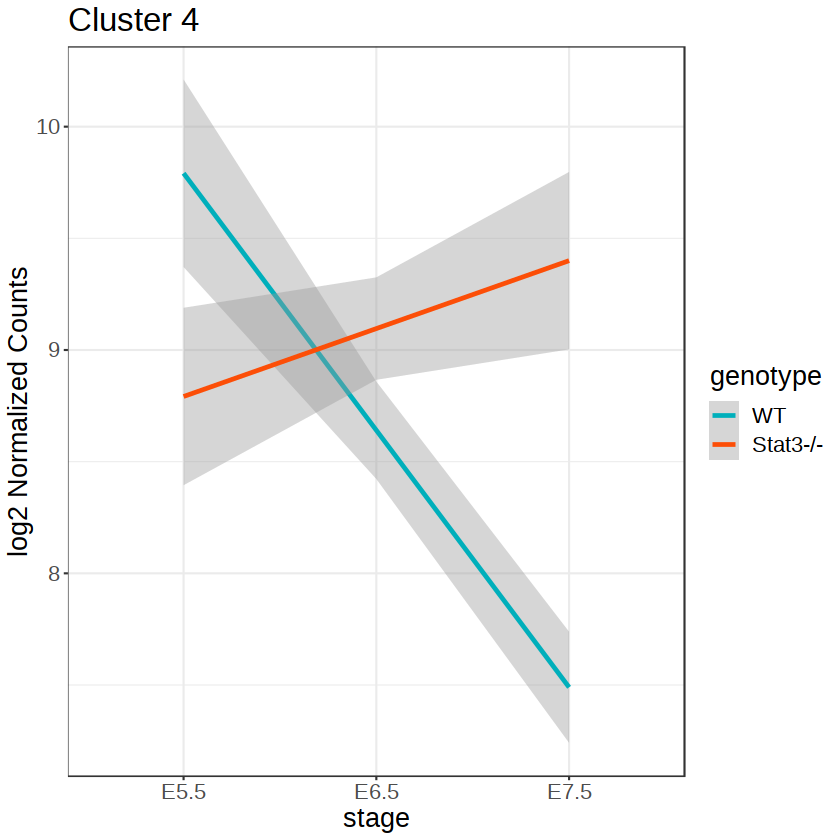

Warning message in write.csv(c5genes, "Cluster5Genes_100522.csv", row.names = F, :
“attempt to set 'col.names' ignored”


png 
  2

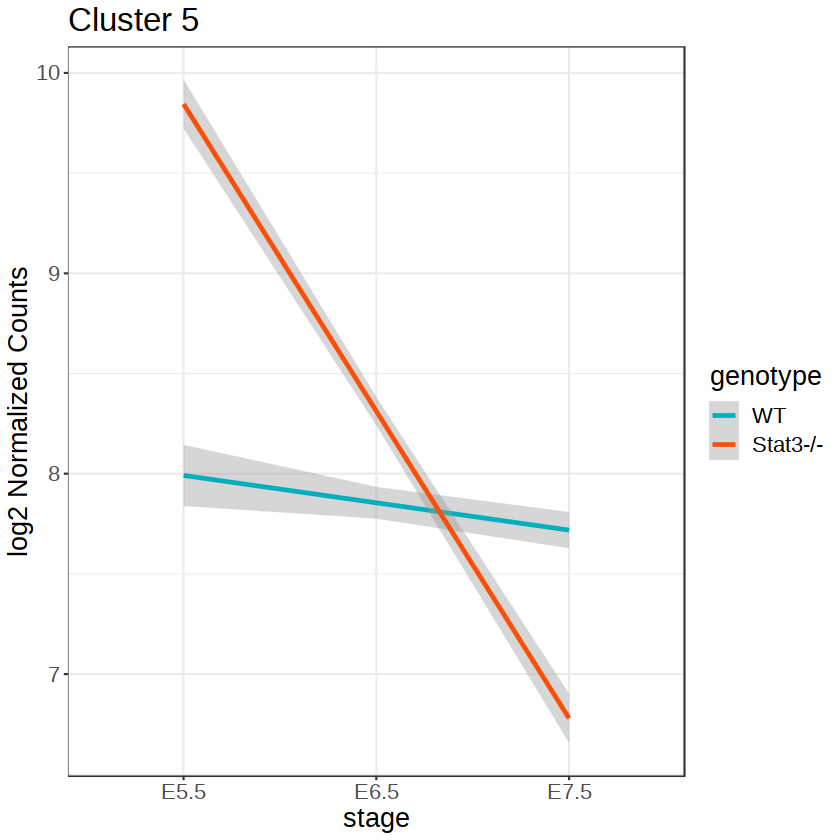

In [35]:
#Plot for gene of c1

rldE567 <- assay(rld_E567)
rldE567 <- as.data.frame(rldE567)
rldE567$gene <- rownames(rldE567)
#selected genes
c1genes <- rownames(c1)
gene_c1 <- assay(rld_E567[c1genes, ])
head(gene_c1)
# First compare wide vs long version
rldE567_c1_long <- melt(gene_c1, id.vars=c("gene"))
colnames(rldE567_c1_long) <- c("gene", "sample", "normalized_count")
head(rldE567_c1_long)

phenodata_epi <- read.csv("phenodata_epi2.csv")
rldE567_c1_long <- inner_join( phenodata_epi, rldE567_c1_long, by = "sample")
rldE567_c1_long$genotype <- factor(rldE567_c1_long$genotype, levels = c("WT", "Stat3-/-"))

#plot c1 genes
c1plot <- rldE567_c1_long %>%
  ggplot(aes(stage, normalized_count, group = genotype, color = genotype)) +
  scale_color_manual(values = c("#00afbb", "#fc4e07")) +
  geom_smooth(method = "lm", formula = 'y ~ x') +
  theme_bw(base_size = 10) +
  theme(text = element_text(size = 16)) +
  xlab("stage") +
  ylab("log2 Normalized Counts") +
  ggtitle("Cluster 1")

print(c1plot)
write.csv(c1genes, "Cluster1Genes_100522.csv", row.names = F, col.names = F)

#Plot for gene of c2

rldE567 <- assay(rld_E567)
rldE567 <- as.data.frame(rldE567)
rldE567$gene <- rownames(rldE567)
#selected genes
c2genes <- rownames(c2)
gene_c2 <- assay(rld_E567[c2genes, ])
head(gene_c2)
# First compare wide vs long version
rldE567_c2_long <- melt(gene_c2, id.vars=c("gene"))
colnames(rldE567_c2_long) <- c("gene", "sample", "normalized_count")
head(rldE567_c2_long)

rldE567_c2_long <- inner_join( phenodata_epi, rldE567_c2_long, by = "sample")
rldE567_c2_long$genotype <- factor(rldE567_c2_long$genotype, levels = c("WT", "Stat3-/-"))

#plot c2 genes
c2plot <- rldE567_c2_long %>%
  ggplot(aes(stage, normalized_count, group = genotype, color = genotype)) +
  scale_color_manual(values = c("#00afbb", "#fc4e07")) +
  geom_smooth(method = "lm", formula = 'y ~ x') +
  theme_bw(base_size = 10) +
  theme(text = element_text(size = 16)) +
  xlab("stage") +
  ylab("log2 Normalized Counts") +
  ggtitle("Cluster 2")

print(c2plot)
write.csv(c2genes, "Cluster2Genes_100522.csv", row.names = F, col.names = F)




#Plot for gene of c3

rldE567 <- assay(rld_E567)
rldE567 <- as.data.frame(rldE567)
rldE567$gene <- rownames(rldE567)
#selected genes
c3genes <- rownames(c3)
gene_c3 <- assay(rld_E567[c3genes, ])
head(gene_c3)
# First compare wide vs long version
rldE567_c3_long <- melt(gene_c3, id.vars=c("gene"))
colnames(rldE567_c3_long) <- c("gene", "sample", "normalized_count")
head(rldE567_c3_long)

rldE567_c3_long <- inner_join( phenodata_epi, rldE567_c3_long, by = "sample")
rldE567_c3_long$genotype <- factor(rldE567_c3_long$genotype, levels = c("WT", "Stat3-/-"))

#plot c3 genes
c3plot <- rldE567_c3_long %>%
  ggplot(aes(stage, normalized_count, group = genotype, color = genotype)) +
  scale_color_manual(values = c("#00afbb", "#fc4e07")) +
  geom_smooth(method = "lm", formula = 'y ~ x') +
  theme_bw(base_size = 10) +
  theme(text = element_text(size = 16)) +
  xlab("stage") +
  ylab("log2 Normalized Counts") +
  ggtitle("Cluster 3")

print(c3plot)
write.csv(c3genes, "Cluster3Genes_100522.csv", row.names = F, col.names = F)



#Plot for gene of c4

rldE567 <- assay(rld_E567)
rldE567 <- as.data.frame(rldE567)
rldE567$gene <- rownames(rldE567)
#selected genes
c4genes <- rownames(c4)
gene_c4 <- assay(rld_E567[c4genes, ])
head(gene_c4)
# First compare wide vs long version
rldE567_c4_long <- melt(gene_c4, id.vars=c("gene"))
colnames(rldE567_c4_long) <- c("gene", "sample", "normalized_count")
head(rldE567_c4_long)

rldE567_c4_long <- inner_join( phenodata_epi, rldE567_c4_long, by = "sample")
rldE567_c4_long$genotype <- factor(rldE567_c4_long$genotype, levels = c("WT", "Stat3-/-"))

#plot c4 genes
c4plot <- rldE567_c4_long %>%
  ggplot(aes(stage, normalized_count, group = genotype, color = genotype)) +
  scale_color_manual(values = c("#00afbb", "#fc4e07")) +
  geom_smooth(method = "lm", formula = 'y ~ x') +
  theme_bw(base_size = 10) +
  theme(text = element_text(size = 16)) +
  xlab("stage") +
  ylab("log2 Normalized Counts") +
  ggtitle("Cluster 4")

print(c4plot)
write.csv(c4genes, "Cluster4Genes_100522.csv", row.names = F, col.names = F)

#Plot for gene of c5

rldE567 <- assay(rld_E567)
rldE567 <- as.data.frame(rldE567)
rldE567$gene <- rownames(rldE567)
#selected genes
c5genes <- rownames(c5)
gene_c5 <- assay(rld_E567[c5genes, ])
head(gene_c5)
# First compare wide vs long version
rldE567_c5_long <- melt(gene_c5, id.vars=c("gene"))
colnames(rldE567_c5_long) <- c("gene", "sample", "normalized_count")
head(rldE567_c5_long)

rldE567_c5_long <- inner_join( phenodata_epi, rldE567_c5_long, by = "sample")
rldE567_c5_long$genotype <- factor(rldE567_c5_long$genotype, levels = c("WT", "Stat3-/-"))

#plot c5 genes
c5plot <- rldE567_c5_long %>%
  ggplot(aes(stage, normalized_count, group = genotype, color = genotype)) +
  scale_color_manual(values = c("#00afbb", "#fc4e07")) +
  geom_smooth(method = "lm", formula = 'y ~ x') +
  theme_bw(base_size = 10) +
  theme(text = element_text(size = 16)) +
  xlab("stage") +
  ylab("log2 Normalized Counts") +
  ggtitle("Cluster 5")

print(c5plot)
write.csv(c5genes, "Cluster5Genes_100522.csv", row.names = F, col.names = F)





library(patchwork)
comb <- ((c1plot/c2plot/c3plot/c4plot)&theme(legend.position="none"))/(c5plot*theme(legend.position="bottom"))

pdf("E567_DEGs_cluster_plot_100522.pdf", height = 14, width = 4)
print(comb)
dev.off()









